<h1 style="text-align: center;">Uma introdução ao XGBoost aplicada à previsão da tensão de escoamento de aços</h1>

__Autor__: Matheus Luiz Mendes de Souza

__Disciplina__: Aprendizado de máquina (segundo semestre)

__Docente__: Prof. Dr. Daniel Roberto Cassar

__Instituição__: Ilum - Escola de Ciência (CNPEM)

11/09/2026

# Introdução

O aprendizado de máquina (machine learning) é uma área da inteligência artificial que induz algoritmos capazes de reconhecer padrões de dados e fazer predições com base no treinamento e no teste, sem necessitar de programação manual para cada regra. Na ciência, ela acelera descobertas ao processar grandes volumes de informações em diferentes áreas do conhecimento.

Neste notebook didático, um dos algoritmos mais utilizados para essas predições será introduzido: o XGBoost. Com isso, além de compreendermos questões fundamentais da matemática e estatística que permeiam o algoritmo, também veremos se é possível aplicá-lo em uma base de dados para prever a tensão de escoamento de aços com base em um conjunto de dados da biblioteca __Matminer__.

### O problema científico

Na área de ciência dos materiais, diferentes composições químicas podem levar a diferentes propriedades mecânicas. Uma propriedade particularmente importante é a tensão de escoamento, que é uma medida da tensão associada ao início do comportamento plástico do material, isto é, à ocorrência de deformação permanente.

Com base nisso, a escolha de um material para determinadas aplicações depende das suas propriedades. No caso dos aços, uma propriedade importante é a tensão de escoamento. Nesse contexto, pequenas mudanças em sua composição química podem estar relacionadas a diferenças grandes no seu comportamento mecânico.

Determinar experimentalmente propriedades de materiais demanda tempo, recursos e a preparação de amostras. Surge então a pergunta: com base em dados de materiais que conhecemos tanto a composição quanto a tensão de escoamento, seria possível utilizar essas informações para construir um modelo capaz de estimar essa propriedade? Observa-se, assim, a utilidade do machine learning nesse caso, visto que um bom modelo facilitaria todo esse processo.

Portanto, nesse notebook, vamos investigar até que ponto um modelo de aprendizado de máquina pode aprender padrões presentes nos dados que permitam estimar a tensão de escoamento a partir da composição química.

# Antes do XGBoost: o problema de aprendizado supervisionado

Antes de compreendermos o algoritmo do XGBoost, precisamos ter os fundamentos do machine learning bem firmados para que o leitor possa compreender o avanço dos algoritmos até chegarmos ao XGBoost. 



## Features e Target

A princípio, a área de machine learning (ML) possui algumas subdivisões, uma delas é o __aprendizado supervisionado__. Nela, os algoritmos induzem modelos preditivos que recebem um ou mais **features** (também conhecidos como atributos) e retornam uma previsão de um ou mais **targets** (valores que queremos prever).

No nosso caso, temos como features a composição química do aço e, com base nessas features, queremos prever qual é a sua tensão de escoamento (assim, a tensão de escoamento é o nosso target). Sendo X as variáveis de entrada (composição química) e y a variável que queremos prever (a tensão de escoamento), teremos nos dados vários valores de  $(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$  como exemplo. A partir desse conjunto de valores, treinaremos o algoritmo para que ele possa prever a tensão de escoamento de aços com base na sua composição química, possuindo, assim uma função $\hat{y} = f(X)$.   

Por fim, como o nosso __target__ a ser predito é uma variável __numérica__, teremos que o problema que será resolvido é um __problema de regressão__.

## Treinamento e teste

Para não superestimar o desempenho do modelo que será induzido, não podemos testar o modelo com os mesmos dados utilizados. A partir disso, uma ótima estratégia para induzir um bom modelo é a estratégia de __train test split__, que consiste em reservar uma fração arbitrária dos dados que temos (nesse caso, seguiremos o que a literatura recomenda) e usar apenas o restante dos dados para o treino do modelo. Após o treino, nós tentamos prever os dados que reservamos e, com isso, checamos se o modelo tem um desempenho razoável quando tenta prever dados que não conhece. Visualmente, o seguinte diagrama ajuda a entender esse processo:

```
Dados disponíveis
       │
       ├───────────────┐
       ↓               ↓
 Treinamento          Teste
       │               │
       ↓               ↓
 Aprender f(X)     Avaliar f(X)
```
Fonte: produzido pela IA generativa Chat-GPT

O aprendizado dos modelos que serão induzidos dependem dos hiperparâmetros escolhidos. Nesse sentido, __hiperparâmetros__ são variáveis de configuração externas definidas manualmente antes do treinamento para controlar como o modelo de aprendizado de máquina aprende. Em cada sessão de modelos, discutiremos os hiperparâmetros daquele modelo e mostraremos a sua influência no aprendizado e desempenho do modelo.

## Como avaliar uma regressão?

As métricas de avaliação fazem o trabalho de quantificar o quão próximo o modelo chega dos valores reais, utilizando diferentes cálculos para medir o erro entre as previsões e os resultados já observados. Existem diversas métricas para medir o desempenho de modelos de regressão,  mas, para esse notebook, utilizaremos apenas 3. Sendo elas: a métrica do erro médio absoluto (MAE), a métrica da raiz do erro quadrático médio (RMSE) e o $R^2$, visto que são intuitivas e fornecem a informação necessária sobre o desempenho. Essa combinação é interessante, pois o MAE e o RMSE medem coisas diferentes e um pode complementar o outro, visto que o RMSE é mais sensível à outliers. O $R^2$ é utilizado como uma medida complementar para avaliar o desempenho do modelo em relação à variabilidade observada nos dados.

###  Erro médio absoluto (MAE)

O erro médio absoluto é uma métrica que indica a __magnitude média dos erros em um conjunto de previsões__, calculando a média das diferenças absolutas entre os valores reais e os valores previstos pelo modelo. Uma característica importante do MAE é que grandes desvios não são penalizados de forma desproporcional, então a presença de outliers não tem impacto tão grande no resultado, o que pode ser uma vantagem. Por outro lado, em casos onde o modelo apresenta erros por grandes margens, o resultado do MAE pode não refletir bem o impacto desses desvios. Sua fórmula é dada por:

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

em que:

-   $y_i$ é o target do exemplo $i$ (valor que conhecemos, pode ser chamado de &ldquo;$y$ verdadeiro&rdquo; ou &ldquo;$y$ true&rdquo; na literatura);

-   $\hat{y}_i$ é o valor previsto para o exemplo $i$;

-   e $n$ é o número de exemplos do conjunto de dados que estamos computando a métrica.

###  Métrica da raiz do erro quadrático médio (RMSE)

O RMSE (Root Mean Squared Error) mede a magnitude dos erros de previsão, __calculando a raiz quadrada da média dos erros quadráticos__. Essa métrica é mais sensível a grandes desvios, pois o erro é elevado ao quadrado, o que significa que grandes diferenças entre o valor previsto e o valor real terão um grande impacto no resultado. O RMSE é ideal para cenários onde grandes desvios são considerados prejudiciais e devem ser minimizados.

Sua fórmula está expressa abaixo:

$$
\mathrm{RMSE} = \sqrt{\mathrm{MSE}} = \sqrt{\sum_{i=1}^{n} \frac{(y_i - \hat{y}_i)^2}{n}}.
$$


em que:

-   $y_i$ é o target do exemplo $i$;

-   $\hat{y}_i$ é o valor previsto para o exemplo $i$;

-   e $n$ é o número de exemplos do conjunto de dados que estamos computando a métrica.

### $R^2$ - Coeficiente de Determinação

O Coeficiente de Determinação é uma métrica que mede o quanto da variabilidade da variável resposta é explicada pelo modelo. Em outras palavras, ele mostra a proporção da variância dos valores observados que é capturada pelas previsões do modelo.

O valor de R² indica o quanto o modelo se ajustou bem aos dados, em que, valores próximos de 1 indicam que o modelo explica uma grande parcela da variabilidade observada. Um valor de R² igual a 0 indica desempenho equivalente ao uso da média do target como predição, enquanto valores negativos indicam desempenho inferior a essa referência.

Porém, existem algumas limitações. O R² pode ter resultados enganadores quando existem outliers ou em relações não-lineares entre as variáveis. 


$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$


em que:

-   $y_i$ é o target do exemplo $i$;

-   $\hat{y}_i$ é o valor previsto para o exemplo $i$;

- $\bar{y}$ é o valor da média dos valores reais.

# Árvores de decisão para regressão

Aqui iniciamos o nosso breve caminho para chegar no nosso algoritmo. Leia atentamente, pois esse 'caminho de algoritmos' será fundamental para o entendimento do XGBoost.

## A ideia de uma árvore

As árvores de decisão são um tipo de modelo que funciona de maneira parecida com um __fluxograma__. A estrutura do modelo é separada em __nós de decisão__, em que cada nó interno representa uma condição ou regra que __divide__ os dados.

Esses __nós__ continuam tomando decisões até chegar aos __"nós folha"__, representando o resultado ou a previsão final.Dessa forma, a árvore é o conjunto total dos nós (da raiz até as folhas). 

As árvores de decisão aplicam o princípio de "dividir para conquistar", decompondo um problema complexo em subproblemas menores e mais simples. Esse processo é realizado de forma recursiva, e as soluções obtidas para cada subproblema são organizadas em uma estrutura hierárquica que permite chegar à solução do problema original (FACELI et al., 2021).

A árvore simples ilustrada na __figura 1__ mostra bem o conceito de uma árvore de decisões:

__Figura 1__ - Estrutura de uma árvore de decisão.

<div align="center">
<img src=https://cdn-wcsm.alura.com.br/2025/04/arvore-gif.gif width=500" alt="Texto alternativo">
</div>

Fonte: Alura (2024) [1].

Na __figura 1__ é possível observar que a árvore inicia no __nó raiz__, que possui a primeira decomposição do problema. Após isso, os __nós internos__ continuam a decomposição do problema até chegar aos __vértices folha__, representando as __conclusões finais__, isto é, as respostas para o problema de acordo com as decisões da árvore.

## Como uma árvore aprende?

Pensando em __problemas de regressão__, a indução de uma árvore de decisão envolve escolher os condicionais dos vértices que não são os vérices folha. Nesse caso, os condicionais escolhidos são aqueles que mais diminuem o valor da soma dos resíduos quadrados após o __split__ (divisão). Para calcular essa soma, computamos a média dos dados de cada vértice filho e calculamos o __resíduo quadrado dos dados com relação a essa a média__. 

Lembre-se que __já abordamos a métrica da raiz quadrada dos resíduos quadrados em sessões anteriores (RMSE)__, para as árvores de regressão, o raciocínio é o mesmo, só que a raiz não é calculada, sendo assim, o resíduo quadrado dos dados (MSE).

Com isso, tenha em vista o seguinte raciocínio:

<div align="center">
<b>
O objetivo da árvore é encontrar as divisões que minimizem o Erro Quadrático Médio. Quanto menor o erro, mais próximas estão as previsões feitas pelo modelo dos valores reais. Dessa forma, o modelo testa várias divisões possíveis e adota aquelas que resultam no menor MSE, garantindo previsões mais precisas.
</b>
</div>

## Um problema possível: overfitting

O sobreajuste (overfitting) é um problema que ocorre quando o modelo se ajusta excessivamente aos dados de treinamento, capturando até mesmo o ruído ou variações irrelevantes dos dados, em vez de aprender padrões generalizáveis. Esse problema é influenciado pela profundidade (depth) da árvore de decisões. O hiperparâmetro __max_depth__ controla a complexidade geral da árvore de decisão. Por meio dele, pode-se fazer o "trade-off" (equilíbrio) entre o __underfitting__ e o __overfitting__ da árvore. Na próxima sessão, vamos variar esse hiperparâmetro e observar, na prática, os efeitos gerados pela variação dele.

As árvores de decisão também possuem outros hiperparâmetros que podem ser alterados, os principais (além da profundidade), são: 

-   __max_leaf_nodes__: controla o número máximo de vértices folha na árvore de decisão. O valor padrão é `None` que indica para o `scikit-learn` que não existe limite para esse número.

-   __min_samples_split__: número mínimo de exemplos necessários para que um vértice possa ser um vértice de decisão (em outras palavras, número mínimo de exemplos para que haja split dos dados). Vértices com menos exemplos que `min_samples_split` são obrigados a serem vértices folha. O valor padrão do `scikit-learn` é 2.

-   __min_samples_leaf__: número mínimo de exemplos permitidos em um vértice folha. O valor padrão do `scikit-learn` é 1.

Para o leitor mais curioso, os demais hiperparâmetros podem ser consultados na [documentação](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) do Scikit-learn.

__Vamos lembrar de uma coisa fundamental__: o objetivo principal da indução de modelos não é predizer perfeitamente os dados desconhecidos (isso ocorreria apenas em uma realidade utópica), na verdade, estamos buscando compreender os padrões presentes nos dados e generalizá-los para prever de maneira geral os dados desconhecidos.

## Pequeno exemplo prático

Para que possamos visualizar, na prática, o funcionamento de uma árvore de decisões, é interessante observarmos um __exemplo básico__ com um dataset didático. Para isso, precisamos importar o módulo __Scikit-learn__, que será muito utilizado nesse notebook para induzir os modelos.

A princípio, é necessário importar as bibliotecas e carregar os dados:

In [1]:
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from matplotlib import pyplot as plt

NOME_DATASET = "penguins"
ATRIBUTOS = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
TARGET = ["body_mass_g"]

df = sns.load_dataset(NOME_DATASET)

df = df.reindex(ATRIBUTOS + TARGET, axis=1)
df = df.dropna()

Vamos, agora, utilizar a estratégia apresentada anteriormente para separar os dados de treino e de teste.

In [2]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 210906

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

Primeiramente, criamos uma instância do modelo. Neste momento, iremos definir o hiperparâmetro max_depth. A profundidade, como já discutimos anteriormente, está totalmente ligada à complexidade da árvore de decisão e pode ser controlada por esse parâmetro.

Vamos iniciar com ele igual à 2 e, então, vamos variar e observar.

In [3]:
from sklearn.tree import DecisionTreeRegressor

PROFUNDIDADE = 2

modelo2 = DecisionTreeRegressor(max_depth=PROFUNDIDADE)
modelo2.fit(X_treino, y_treino)

y_verdadeiro2 = y_teste
y_previsto2 = modelo2.predict(X_teste)

Como vamos observar o gráfico do modelo para observarmos os fenômenos de underfit e overfit, necessita-se dos módulos que farão a plotagem.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Agora, observar graficamente o modelo e checar seu desempenho.

O RMSE do modelo árvore de decisão foi de 481.6696896888586 unidades de y.


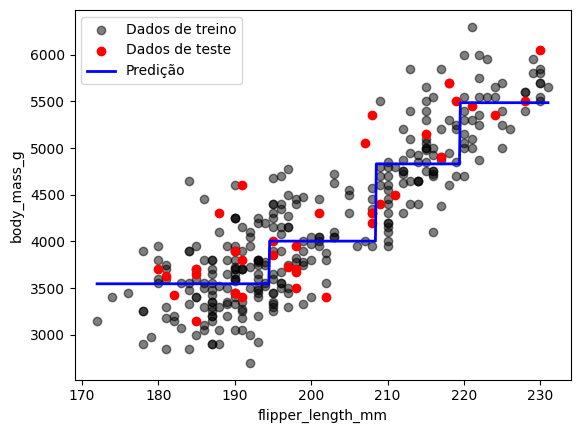

In [5]:
from sklearn.metrics import root_mean_squared_error

RMSE = root_mean_squared_error(y_verdadeiro2, y_previsto2)

print(f"O RMSE do modelo árvore de decisão foi de {RMSE} unidades de y.")

"""Para cada valor de flipper_length_mm, mostre qual body_mass_g o modelo prevê."""

X_linha2 = np.linspace(
    X_treino[:, 2].min(),
    X_treino[:, 2].max(),
    500
)

X_pred2 = np.column_stack([
    np.full(500, X_treino[:, 0].mean()),
    np.full(500, X_treino[:, 1].mean()),
    X_linha2
])

y_linha2 = modelo2.predict(X_pred2)


plt.scatter(
    X_treino[:, 2],
    y_treino,
    color="black",
    alpha=0.5,
    label="Dados de treino"
)

plt.scatter(
    X_teste[:, 2],
    y_teste,
    color="red",
    label="Dados de teste"
)

plt.plot(
    X_linha2,
    y_linha2,
    color="blue",
    linewidth=2,
    label="Predição"
)

plt.xlabel("flipper_length_mm")
plt.ylabel("body_mass_g")
plt.legend()
plt.show()


Pelo gráfico, observamos que a predição do modelo é razoável e tem uma aparência de 'escada'. Isso porque, a profundidade tem valor 2 e a árvore não faz muitas divisões no eixo x. Ao observar a legenda, notamos também que os dados de teste tiveram uma diferença notável do previsto, fato que é observado pelo RMSE do modelo de 481,66 gramas (um erro bem grande). Com isso, temos que, para max_depth = 2, o modelo tem um desempenho razoável, mas, ainda sim, não parece prever satisfatoriamente os dados.

### Profundidade = 30 e o evento de Overfitting

Agora, vamos observar o fenômeno de Overfitting ao aumentar drasticamente o valor do parâmetro max_depth da árvore (dado pela profundidade). A princípio, vamos treinar o modelo com maior profundidade:

In [6]:
PROFUNDIDADE = 30

modelo30 = DecisionTreeRegressor(max_depth=PROFUNDIDADE)
modelo30.fit(X_treino, y_treino)

y_verdadeiro = y_teste
y_previsto30 = modelo30.predict(X_teste)

Agora vamos plotar o seu RMSE e o gráfico com a predição.

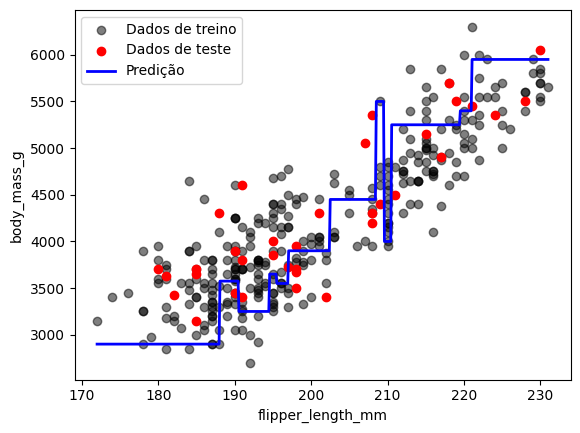

O RMSE do modelo árvore de decisão foi de 429.0354630696961 unidades de y.


In [7]:
"""Para cada valor de flipper_length_mm, mostre qual body_mass_g o modelo prevê."""

X_linha30 = np.linspace(
    X_treino[:, 2].min(),
    X_treino[:, 2].max(),
    500
)

X_pred30 = np.column_stack([
    np.full(500, X_treino[:, 0].mean()),
    np.full(500, X_treino[:, 1].mean()),
    X_linha30
])

y_linha30 = modelo30.predict(X_pred30)

plt.scatter(
    X_treino[:, 2],
    y_treino,
    color="black",
    alpha=0.5,
    label="Dados de treino"
)

plt.scatter(
    X_teste[:, 2],
    y_teste,
    color="red",
    label="Dados de teste"
)

plt.plot(
    X_linha30,
    y_linha30,
    color="blue",
    linewidth=2,
    label="Predição"
)

plt.xlabel("flipper_length_mm")
plt.ylabel("body_mass_g")
plt.legend()
plt.show()

RMSE = root_mean_squared_error(y_verdadeiro, y_previsto30)

print(f"O RMSE do modelo árvore de decisão foi de {RMSE} unidades de y.")

Pelo gráfico, podemos observar o fenômeno de overfit que uma profundidade grande gera no modelo. Nesse caso, o modelo ficou otimamente ajustado para os dados de treinamento. Entretanto, ao criarmos um modelo, não buscamos um modelo com alta variância (como esse), mas sim um modelo que possua equilíbrio entre a variância e o viés (subajuste). Dessa forma, buscamos um modelo equilíbrado que possa identificar os padrões dos dados e fazer uma predição satisfatória dos dados desconhecidos.

O RMSE diminuiu minimamente, mas o modelo ainda é ruim. Apesar disso, podemos compreender como a variação da profundidade da árvore altera o comportamento do modelo induzido.

Uma profundidade baixa geraria um alto viés. O viés é o erro gerado por suposições excessivamente simples no algoritmo e leva ao fenômeno de underfitting, em que ele não consegue captar a complexidade dos dados de treino e nem predizer satisfatoriamente os dados de teste. Não vamos hiperfocar nesse fenômeno, pois, para o XGBoost, a maior preocupação é o overfitting.

O modelo de aprendizado de máquina 'ideal', portanto, é aquele que possui equilíbrio entre o viés e a variância e prediz bem os dados desconhecidos, assim como capta os padrões dos dados de treino.

Ao fim dessa sessão, uma pergunta naturalmente começa a surgir:

> Se uma árvore possui limitações, será que várias árvores poderiam produzir um modelo melhor?

# De uma árvore para várias: Ensemble Learning

## A ideia de combinar modelos

Vimos que as árvores de decisão são poderosas, porém, elas possuem limitações (como vimos anteriormente). Nessa sessão do notebook, vamos estudar formas de conseguir vencer essas limitações, sendo uma delas a criação de ensembles para induzir modelos que fazer melhores predições.

Para iniciar, a própria palavra 'ensemble' trás um significado fundamental para compreender essa técnica.

>Em inglês, ensemble significa um grupo de coisas ou pessoas que funcionam juntas como um todo, ou um traje coordenado.

A partir dessa definição do <a href="https://dictionary.cambridge.org/pt/dicionario/ingles/ensemble">Cambridge Dictionary</a>, fica mais fácil de interpretar a técnica. Simploriamente, ela combina múltiplos modelos individuais chamado base learners ou weak learners, para criar um único e preciso sistema para predição. 

Essa estratégia pode ser utilizada para problemas de regressão e de classificação. Contudo, como o nosso foco, nesse notebook, são problemas de regressão, focaremos neles.

## Bagging e Random forests

### Bagging

O algoritmo de Bagging tem como principal função tentar evitar o overfitting. Ele faz isso construindo vários estimadores, usando o mesmo modelo várias vezes para, depois, fazer uma média (em casos de regressão) somando esses modelos individuais, conforme o agrupamento existente nos Métodos Ensemble.

Primordialmente, deve-se escolher qual o modelo que será usado. Por exemplo, podemos optar pelo algoritmo de árvore de decisão, KNN, Regressão Linear, etc. 

Então, ao escolher o modelo, o algoritmo de Bagging construirá várias vezes esse algoritmo. A partir de um conjunto de dados, o algoritmo de Bagging irá induzir o primeiro modelo (uma árvore de decisão, por exemplo); depois ele induzirá um segundo, o terceiro... e assim por diante, de acordo com o número de modelos que pedimos para o algoritmo induzir.

Por fim, ele utilizará os resultados individuais de cada modelo para, através da média, apresentar o seu resultado final.

O Bagging faz uma seleção aleatória das amostras. Para fazer a primeira árvore de decisão, ele escolhe um conjunto específico de amostras, sorteando algumas do conjunto total de dados. Com esse dataset ele escolhe cinco mil amostras de um total de dez mil, por exemplo, para a construção da árvore. Também é possível escolher a fração das amostras por porcentagem.

O processo ocorre dessa forma: o Bagging faz um sorteio de todas as amostras; escolhe uma e, depois, faz outro sorteio e escolhe a segunda; e, dessa forma, ele segue sorteando as cinco mil amostras.

Ele utiliza a técnica de reamostragem de __Bootstrapping__, que cria vários datasets a partir de um dataset original, criando subconjuntos com tamanhos iguais, por meio de reamostragem com reposição, ou seja, cada ponto de dado pode ser sorteado várias vezes ou nenhuma em um mesmo subconjunto.

É dessa forma que o Bagging consegue construir estimadores diferentes: __ele usa o mesmo algoritmo, só que para cada estimador, criado separadamente, ele usa um conjunto diferente de amostras__.

A figura 2, ilustra bem o procedimento de __Bagging__:

__Figura 2__ - O processo de Bagging.

<div align="center">
<img src=https://miro.medium.com/v2/resize:fit:1100/format:webp/1*a6hnuJ8WM37mLimHfMORmQ.png width=500" alt="Texto alternativo">
</div>

Fonte: Soni (2023) [2].


### Random Forest

Uma floresta aleatória, como o próprio nome já diz, irá criar muitas árvores de decisão de maneira aleatória, formando 'florestas', em que cada árvore será utilizada na escolha do resultado final.

Como um bom método ensemble, serão criados vários modelos a partir de um algortimo, de forma que todos serão utilizados para alcançar um resultado final. 

Diferentemente do que acontece na criação de uma árvore de decisão simples, ao utilizar o __RandomForest__, o primeiro passo executado pelo algoritmo será selecionar aleatoriamente algumas amostras dos dados de treino, e não a sua totalidade, utilizando, como vimos anteriormente, o boostrap.

Conforme vimos nos detalhes sobre a construção de uma árvore de decisão, para começar é preciso definir o primeiro nó da árvore (nó raiz), que será a primeira condição verificada, dando origem aos dois primeiros ramos. Utilizando o __algoritmo de entropia__ ou o __índice Gini__, será escolhida a melhor variável para compor o nó raiz, variando de acordo com o método utilizado.

No RandomForest a definição desta variável não acontece com base em todas as variáveis disponíveis. O algoritmo irá escolher de maneira aleatória (random) duas ou mais variáveis, e então realizar os cálculos com base nas amostras selecionadas, para definir qual dessas variáveis será utilizada no primeiro nó.

É evidente que este não é o melhor método para construção de uma árvore de decisão. O algoritmo pode, sem querer, selecionar as duas piores variáveis na primeira seleção, escolhendo uma variável péssima para o primeiro nó. Mas como serão construídas muitas árvores, essa estratégia se torna poderosa, e costuma evitar o overfitting.

#### Construção das próximas árvores

Na construção da próxima árvore, os dois processos anteriores se repetirão, levando a criação de uma nova árvore. __Provavelmente essa árvore será diferente da primeira__, pois tanto na seleção das amostras, quanto na seleção das variáveis, o processo acontece de maneira aleatória.

Podemos construir quantas árvores quisermos, sendo que quanto mais árvores criadas, melhor serão os resultados do modelo, até determinado ponto, onde uma nova árvore não conseguirá levar a uma melhora significativa no desempenho do modelo.

Por fim, com o modelo devidamente induzido, pode-se apresentar novos dados e obter o resultado da previsão. __Cada árvore induzida irá apresentar o seu resultado__, sendo que em problemas de regressão será realizada a __média dos valores previstos__, e esta média informada como resultado final, e em __problemas de classificação o resultado que mais vezes foi apresentado (moda) será o escolhido__.

Na figura 3, é ilustrada um exemplo visual de uma floresta aleatória:

__Figura 3__ - Um exemplo visual de uma random forest.

<div align="center">
<img src=https://miro.medium.com/v2/resize:fit:1100/format:webp/1*SSLTg4ayllaSEDrg1iLIug.png width=500" alt="Texto alternativo">
</div>

Fonte: Ray (2025) [3].

## Boosting

O boosting é um método que combina um conjunto de weaklearners para criar um modelo forte e robusto. Ao invés de treinar todos os modelos de uma vez, o boosting treina os modelos de forma sequencial. Isso significa que o cada novo modelo tenra corrigir os erros cometidos pelos modelos anteriores. 

### Boosting x Bagging

A principal diferença entre esses métodos de ensemble, é que, no bagging, os modelos são induzidos paralelamente, enquanto no boosting, eles são induzidos sequencialmente.

Ademais, os dois modelos criam datasets separados de forma diferente, o bagging cria subsets para a indução de um modelo, enquanto o boosting utiliza o mesmo dataset para a indução dos modelos de forma sequencial. Isso significa que uma série de modelos é construída e, a cada nova iteração do modelo, os pesos dos dados mal classificados no modelo anterior são aumentados. Essa redistribuição de pesos ajuda o algoritmo a identificar os parâmetros nos quais ele precisa se concentrar para melhorar seu desempenho.

Como vimos anteriormente, os dois também diferem nos pesos para as predições. No bagging, todas as predições têm os mesmos pesos para a média (regressão) de predição final. Porém, na média de um método boosting, são utilizados pesos para fazer uma média ponderada dos resultados e fazer a predição.

A figura 4, mostra as diferenças entre o método de __Boosting__ e de __Bagging__:

__Figura 4__ - Bagging e Boosting.

<div align="center">
<img src=https://miro.medium.com/v2/resize:fit:1100/format:webp/1*_0Vw9HE1vbhD4ZW3OZZaQQ.png width=500" alt="Texto alternativo">
</div>

Fonte: Ray (2025) [4].

## Gradient Boosting

É uma técnica de machine learning que combina múltiplos modelos de predição 'fracos' em um único ensemble. Esses modelos 'fracos' são geralmente árvores de decisão, que são treinadas sequencialmente para minimizar erros (função de perda) e aumentar a precisão. Um dos benefícios chave desse método é a sua habilidade para minimizar a função de perda por meio de iterações, resultando em um aumento da precisão na predição. 

O gradient boosting funciona dessa forma:

- Primeiramente, o algoritmo inicia com uma predição base que minimiza a função de perda;

- Logo após, ele computa os resíduos que representam o gradiente da função de perda com respeito à predição atual;

- Então ele treina uma noca árvore de decisão para predizer esses gradientes (erros) ao invés do target final;

- O resultado dessa árvore é multiplicado por uma taxa de aprendizado (learning rate) e somado ao modelo acumulado anterior para refinar a previsão;

- Esse processo se repete por várias vezes (iterações), reduzindo o erro a cada nova etapa até formar um modelo robusto e preciso.


### Função de perda e significado de 'Gradient'

Em machine learning, a função de perda é uma função que mapeia a diferença entre as predições do modelo e o valor real dos dados. Ela retorna um valor numérico representando o erro do modelo.

Durante o processo de treino, a função de perda funciona como um guia. No gradient boosting, ela será o guia para as iterações que irão reduzir os resíduos (erro) da predição.

Já vimos exemplos de funções de perda para problemas de regressão anteriormente. Se não se lembra, volte na sessão "Como avaliar uma regressão?". Nesse sentido, as funções de perda mais utilizadas para problemas de regressão são: O erro quadrático médio (MSE), sendo chamado também de L2 loss e o Erro Absoluto Médio (MAE) ou também chamado de L1 loss. As fórmulas de ambos já foram abordadas anteriormente, logo vamos prosseguir com a matemática da técnica.


### Gradient e a matemática

O ponto de partida é o F0, um palpite fixo para todos os dados. Na regressão, esse palpite inicial é quase sempre a média de todos os valores reais.

$$
F_0(x) = \arg\min_{\gamma} \sum_{i=1}^N L(y_i, \gamma)
$$

>$F_0(x)$: É a previsão inicial (o "chute zero") que o modelo vai dar para todo mundo da sua base de dados, antes de começar a criar as árvores.

>${\sum _{i=1}^{N}}$: Esse símbolo de somatório significa simplesmente: "vamos somar o resultado de todas as linhas de dados, da primeira ($i=1$) até a última ($N$)".

>$L(y_i, \gamma)$: É a Função de Perda (Loss). Ela calcula o tamanho do erro entre o valor real ($y_{i}$) e o chute que estamos testando (${\gamma}$).

>${\arg\min_{\gamma}}$: Essa é a parte mais importante. Ela significa: "encontre o argumento (o valor de ${\gamma}$) que faz a soma dos erros ser a mínima possível".

<br><br>

A função de perda mede o tamanho do erro. Por exemplo, a função do erro quadrático médio calcula:

$$
Perda = (Real-Previsto)^2
$$

De forma genérica, a função de perda pode ser representada da seguinte forma:
$$
L = \sum_{i} L(y_i, \hat{y}_i)
$$

O objetivo da matemática aqui é fazer esse valor se aproximar ao máximo de zero.

<br><br>

É aí que entra o pulo do gato: __O Gradiente__, que dá origem ao nome da técnica.

Na matemática tradicional (cálculo), o gradiente mostra a direção para onde uma função cresce mais rápido. Se formos na direção oposta (descida do gradiente), estamo reduzindo o erro.

No Gradient Boosting, quando calculamos a derivada dessa função de perda em relação à nossa previsão atual, o resultado matemático é simplesmente a diferença entre o real e o previsto:

$$
r_{im} = y_i - F_{m-1}(x_i)
$$

>Para cada linha de dado (i) na rodada atual (m), o algoritmo faz uma subtração simples: Valor Real ($y_{i}$) menos o Valor que o Modelo Previu ($F_{m-1}$). O resultado ($r_{im}$) é o nosso resíduo, ou seja, o erro que o modelo ainda precisa corrigir.

<br><br>

Isso significa que a próxima árvore de decisão do modelo será treinada par prever o erro (resíduo), e não o valor real final.

$$
h_m(x)
$$
>Nós pegamos uma nova árvore de decisão (chamada aqui de $h_{m}$) e a treinamos. Mas ela não tenta adivinhar o resultado final; ela é treinada especificamente para adivinhar os erros ($r_{im}$) calculados no passo anterior.

<br><br>

Se somarmos o erro bruto diretamente à previsão anterior, o modelo sofre overfitting (decora os dados e não generaliza). Por isso, utiliza-se uma taxa de aprendizado (${\alpha}$), que é um número pequeno entre 0.01 e 0.3. Com isso, a fórmula de atualização para o próximo passo ($F1$) fica dessa forma:

$$
F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)
$$

> Para obter a nova previsão melhorada ($F_{m}$), pegamos a previsão antiga ($F_{m-1}$) e somamos a ela o erro que a nova árvore ($h_{m}$) acabou de prever.

Este símbolo (${\nu}$) é a Taxa de Aprendizado (learning rate). Ele geralmente é um número bem pequeno (como 0.1). Ele é utilizado para que o modelo aprenda devagar, dando passos pequenos e sem pressa, o que evita que ele decore os dados perfeitamente (overfitting).

Uma ilustração final é ótima para compreendermos o que acontece nesse processo. A __figura 5__ ilustra como o erro mínimo é encontrado por meio da descida do gradiente:

__Figura 5__ - Descida do gradiente da função de perda.

<div align="center">
<img src=https://cdn-wcsm.alura.com.br/2025/04/gradiente.jpg width=500" alt="Texto alternativo">
</div>

Fonte: Alura (2024) [5].

# E finalmente... O XGBoost

XGBoost, abreviação para eXtreme Gradiente Boosting (Aumento extremo de gradiente), é uma biblioteca de código aberto que se destaca como uma das abordagens mais utilizadas em aprendizado de máquina. Em essência, ele é uma implementação otimizada do gradient boosting, um método que combina vários modelos simples, como árvores de decisão, para formar um preditor mais forte. A ideia central é usar modelos fracos sequencialmente, corrigindo os erros dos anteriores, o que refina as previsões.

O Gradient Boosting fornece uma estrutura poderosa para construir modelos preditivos a partir de árvores de decisão. Entretanto, sua implementação envolve escolhas relacionadas à otimização, controle da complexidade e eficiência computacional. O XGBoost é uma implementação de Gradient Boosting que incorpora estratégias específicas para tornar esse processo mais eficiente e controlar a complexidade dos modelos.


## Diferenças em relação ao Gradient Boosting

A principal diferença do XGBoost para o Gradient Boosting é a regularização. No gradient Boosting que estudamos, temos a função de perda como 
$$
L = \sum_{i} L(y_i, \hat{y}_i)
$$

No XGBoost, a função objetivo incorpora explicitamente uma penalização da complexidade:

$$
L = Loss \sum Regularização
$$

Sendo, representada formalmente por:

$$
\text{Obj} = \sum_{i} l(y_i, \hat{y}_i) + \sum_{k} \Omega(f_k)
$$
> $\sum_{i} l(y_i, \hat{y}_i)$: é a função de perda, que calcula o erro que deve ser minimizado.
 
> $\sum_{k} \Omega(f_k)$: é o termo que mede a complexidade do modelo para impedir o fenômeno de overfitting.

Para entendermos melhor o segundo termo, podemos observar a fórmula $\Omega$ para regularização da complexidade de uma única árvore:

$$
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$
> $\gamma$: O parâmetro de complexidade que penaliza o número de folhas. Um alto valor de $\gamma$ tende a formar árvores menores e mais simples.

> T: o número total de nós (folhas) da árvore.

>$w_j$: o peso para cada folha j.

> $\lambda$: o parâmetro da regularização L2 aplicada para o peso de cada folha. Um valor alto de $\lambda$ diminui os pesos da folha para aproximadamente zero, suavizando a predição do modelo. A principal função de $\lambda$ é controlar o overfitting (sobreajuste), penalizando valores de previsão muito extremos.

<br><br>
O modelo, então, não busca apenas minimizar o erro de previsão, mas também penalizar as árvores excessivamente complexas.

Visualmente:

__Figura 6__ - Esquema que representa as individualidades do XGBoost.
```
             XGBoost
                │
       ┌────────┴────────┐
       ↓                 ↓
 reduzir erro      controlar complexidade
       │                 │
       └────────┬────────┘
                ↓
        modelo mais robusto
```

Fonte: IA generativa Chat GPT. Acesso em: 8 set. 2026.

### Uma outra diferença: derivadas de segunda ordem

No Gradient Boosting, vimos que o gradiente da função de perda utilizado pelas equações provém de uma derivada de primeira ordem. 
$$
g_i = \frac{\partial L}{\partial \hat{y}_i}
$$
>Em termos práticos, o termo $g_{i}$ costuma ser chamado de "gradiente de erro" ou "resíduo" do i-ésimo exemplo durante o processo de otimização.


Porém, o XGBoost vai além e utiliza também derivadas de segunda ordem para a aproximação da função objetivo. 

$$
h_i = \frac{\partial^2 L}{\partial \hat{y}_i^2}
$$

O uso da aproximação de segunda ordem fornece ao XGBoost informações adicionais sobre a função de perda e permite calcular de maneira eficiente os pesos das folhas e avaliar possíveis divisões das árvores.

### A terceira diferença: como as divisões das árvores são avaliadas

No XGBoost, a qualidade de uma divisão pode ser avaliada através de uma expressão de ganho que depende dos gradientes e Hessianas dos exemplos nos nós. A formulação permite decidir se uma divisão realmente melhora o objetivo considerando também a regularização.

De forma básica:

__Figura 7__ - Esquema que representa as divisões das árvores no XGBoost.
```
          Nó atual
             │
       possível divisão
             │
      ┌──────┴──────┐
      ↓             ↓
    Nó L           Nó R
      │             │
      └──────┬──────┘
             ↓
       calcular ganho
             ↓
    ganho suficiente?
        ↙         ↘
      SIM          NÃO
       ↓             ↓
    dividir       não dividir
```

Fonte: IA generativa Chat GPT. Acesso em: 8 set. 2026.

Uma divisão precisa produzir uma redução de perda suficientemente grande para compensar o aumento de complexidade.

## Principais hiperparâmetros

O XGBoost possui muitos hiperparâmetros, porém, como esse notebook é introdutório, escolheremos apenas quatro hiperparâmetros principais para serem estudados e utilizados na simulação, são eles: 

Tabela 1 - Hiperparâmetros

| Hiperparâmetro              | Papel                         |
| --------------------------- | ----------------------------- |
| `n_estimators`              | Número de árvores             |
| `learning_rate`             | Contribuição de cada árvore   |
| `max_depth`                 | Profundidade máxima           |
| `subsample`                 | Fração das amostras utilizada |

Fonte: IA generativa Chat GPT. Acesso em: 8 set. 2026.

### n_estimators

Esse é provavelmente o hiperparâmetro mais intuitivo. Isso porque, ele indica o número de árvores que serão adicionadas no ensemble. Logo, se tivermos, por exemplo n_estimators = 100, teremos, a grosso modo, que o modelo construirá um ensemble com 100 árvores.

Com o aumento de árvores, o modelo fica potencialmente mais poderoso, todavia, o treinamento fica mais demorado e, dependendo dos outros parâmetros, ocorre um risco maior de overfitting.

A ideia didática é:

$$
F(x) = f_1(x) + f_2(x) + \dots + f_M(x)
$$
> Em que M = n _ estimators.

### learning_rate

O learning_rate controla quanto cada árvore contribui para o modelo. Lembrando da equação apresentada em Gradient Boosting:

$$
F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)
$$

>No XGBoost: ${\nu}$= learning_rate.

Então, se tivermos learning_rate = 0.1, teremos que cada árvore tem sua contribuição multiplicada por 0.1.

Além disso, é importante frisar que existe um trade-off entre learning_rate e n_estimators. Frequentemente, um learning rate menor faz com que mais árvores sejam necessárias.

### max_depth

Ele determina a profundidade máxima das árvores. 

Imagine:

<br><br>

__Figura 8__ - Esquema que representa o hiperparâmetro max_depth.

```
max_depth = 1

        ●
       / \

max_depth = 3

             ●
          /     \
         ●       ●
        / \     / \
       ●   ●   ●   ●

```

Fonte: IA generativa Chat GPT. Acesso em: 8 set. 2026.

<br><br>

Um maior valor de max_depth gera árvores mais complexas e aumenta a capacidade do modelo. Entretanto, o aumento desse parâmetro também pode aumentar o risco de overfitting.

### Subsample

Ele controla a fração das amostras utilizadas para induzir cada árvore. Por exemplo, utilizar $subsample = 0.8$ indica que serão utilizadas 80% das amostras em cada etapa. Isso introduz uma espécie de aleatoriedade no processo e pode ajudar na generalização. 

# Aplicação em ciência dos materiais

Agora, com toda a teoria em vista, podemos partir para a resolução do problema especificado na introdução.

## O dataset - previsão da tensão de escoamento de aços

O dataset foi encontrado por meio da biblioteca matminer, que tem diversos datasets focados na área de ciência dos materiais. 

O dataset escolhido foi o matbench_steels um dataset para a previsão da tensão de escoamento dos aços com base na sua composição química. Ele possui 312 amostras e, nesse momento, vamos explorar esse dataset utilizando o módulo pandas.

Após instalar a biblioteca do matminer via pip, podemos iniciar as importações. Caso você não tenha a biblioteca, execute o seguinte código em uma célula:

>pip install matminer

### Carregamento dos dados

Agora vamos importar o módulo pandas e o dataset.

In [8]:
import pandas as pd
from matminer.datasets import load_dataset

df = load_dataset("matbench_steels")

Vamos visualizar algumas informações do dataset e discutir sobre ele.

In [9]:
print(df.shape)

(312, 2)


Podemos, a princípio, notar que o dataset possui 312 linhas e duas colunas.

In [10]:
print(df.head(10))

                                         composition  yield strength
0  Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...          2411.5
1  Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....          1123.1
2  Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....          1736.3
3  Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...          2487.3
4  Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...          2249.6
5  Fe0.636C0.00881Mn0.000203Si0.00972Cr0.135Ni0.0...          1328.3
6  Fe0.644Mn0.000521Si0.00102Cr0.000110Ni0.177Mo0...          2501.1
7  Fe0.646C0.00479Mn0.00597Si0.00492Cr0.135Ni0.00...          1228.9
8  Fe0.648C0.000453Mn0.0000991Si0.0386Cr0.183Ni0....          1088.6
9  Fe0.648C0.00751Mn0.000103Si0.000201Cr0.158Ni0....          1502.0


Apesar de possuirmos uma visualização bem feia, podemos ter uma ideia de como os dados estão organizados. São duas colunas: composition e yield strength. A coluna composition contém fórmulas químicas completas da composição química da amostra, enquanto a coluna yield strength mostra o valor experimental da tensão do escoamento da amostra de aço.

Com isso, temos que as features (valores de entrada) serão os valores utilizados pelo modelo para fazer a predição. Já o target será o valor da tensão de escoamento (em MPa).

### Interpretação física do target

Para refrescar a memória, lembramos que a tensão de escoamento é a máxima tensão que um material suporta antes de começar a se deformar de forma permanente. 

Abaixo desse valor, o material está no regime elástico. Ele deforma com a carga, mas volta ao tamanho e à forma original quando a força é retirada. Acima desse valor, o material entra no regime plástico. A deformação passa a ser definitiva e o objeto não recupera mais suas dimensões iniciais.

Tem importância na engenharia, pois é o parâmetro fundamental para projetar estruturas e peças, garantindo que os componentes operem com segurança sem sofrer danos irreversíveis.

O target é medido em megapascal (MPa), que é uma unidade de medida de pressão e tensão mecânica. 1 MPa representa a força de um newton aplicada sobre uma área de um milímetro quadrado, ou 1.000.000 de newtons por metro quadrado.

## Exploração visual dos dados

### Distribuição da tensão de escoamento

É fundamental visualizamos os dados para observarmos previamente possíveis padrões e, além disso, nos habituarmos com o dataset.

A princípio, podemos plotar a distribuição da tensão de escoamento.

Axes(0.125,0.11;0.775x0.77)


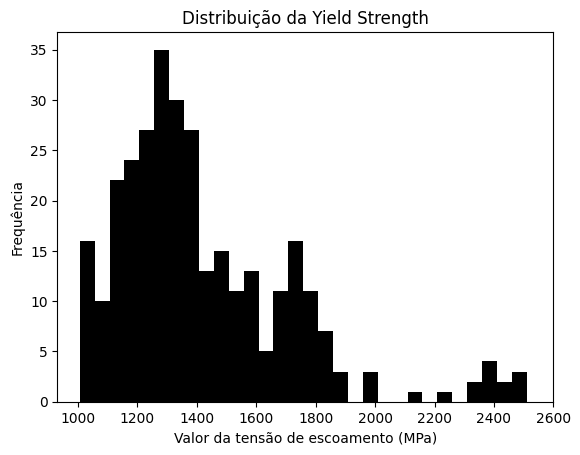

In [11]:
grafico1 = df['yield strength'].plot.hist(title='Distribuição da Yield Strength',bins = 30, ylabel='Frequência', xlabel='Valor da tensão de escoamento (MPa)', color = 'black', yticks=range(0, 40, 5), xticks=range(1000, 2650, 200))
print(grafico1)


Como podemos ver, os valores estão concentrados em uma faixa numérica entre 1000 MPa e 1600 MPa. Há alguns valores mais extremos em cerca de 2400 MPa, porém, é visível uma tendência de concentração de valores em uma faixa mais específica.

### Composição química e ajustes no dataframe

Antes de fazermos a plotagem dos gráficos sobre a composição química, devemos perceber que temos um problema: A coluna de composição está com a composição química representada por apenas uma string em uma linha. Observe o dataframe abaixo para compreender o problema:

In [12]:
df['composition']

0      Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...
1      Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....
2      Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....
3      Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...
4      Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...
                             ...                        
307    Fe0.823C0.0176Mn0.00183Si0.000198Cr0.0779Ni0.0...
308    Fe0.823Mn0.000618Si0.00101Cr0.0561Ni0.0984Mo0....
309    Fe0.825C0.0174Mn0.00175Si0.000201Cr0.0565Ni0.0...
310    Fe0.858C0.0191Mn0.00194Si0.000199Cr0.0753Ni0.0...
311    Fe0.860C0.0125Mn0.00274Si0.000198Cr0.00439Ni0....
Name: composition, Length: 312, dtype: object

Portanto, para plotarmos corretamente e treinarmos o modelo, teremos que separar uma coluna para cada valor de átomo na amostra.

Para isso, utilizaremos o módulo pymatgen, uma biblioteca de código aberto em Python para análise de materiais.

O matbench_steels usa objetos Composition do pymatgen. Podemos aproveitar o próprio pymatgen para extrair a quantidade de cada elemento e separar a quantidade de cada elemento contido na amostra.

In [13]:
from pymatgen.core import Composition

df["composition"] = df["composition"].apply(Composition)


elements = sorted(
    set(
        element.symbol
        for composition in df["composition"]
        for element in composition.elements
    )
)

Com isso, criaremos uma coluna para a quantidade de cada elemento:

In [14]:
for element in elements:
    df[element] = df["composition"].apply(
        lambda composition: composition.get_atomic_fraction(element)
    )

Agora, possuimos o dataframe com várias colunas. Além da tensão de escoamento, temos várias colunas que correspondem à quantidade de cada elemento na amostra (em fração de massa).

Pode-se perceber também que agora teremos várias features, em que cada feature é a quantidade de um elemento em uma determinada amostra.

In [15]:
df.head(10)

,composition,yield strength,Al,C,Co,Cr,Fe,Mn,Mo,N,Nb,Ni,Si,Ti,V,W
0,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)",2411.5,0.003180,0.000953,0.145992,0.000110,0.619964,0.000521,0.017599,0.000000,0.000062,0.191989,0.001020,0.018499,0.000112,0.000000
1,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, N, Nb, Co, W, Al)",1123.1,0.000845,0.008542,0.188034,0.147026,0.623112,0.000104,0.017903,0.001630,0.000061,0.000097,0.000203,0.000000,0.005151,0.007291
2,"(Fe, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)",1736.3,0.008123,0.000000,0.132042,0.093630,0.625199,0.000102,0.004802,0.000000,0.000060,0.129041,0.000200,0.006692,0.000110,0.000000
3,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)",2487.3,0.002772,0.000478,0.146091,0.000111,0.634395,0.000523,0.023715,0.000000,0.000062,0.173108,0.001021,0.017611,0.000113,0.000000
4,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)",2249.6,0.002740,0.000474,0.143997,0.000109,0.635985,0.000518,0.008600,0.000000,0.000061,0.187995,0.001010,0.018400,0.000112,0.000000
5,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al)",1328.3,0.000619,0.008803,0.189840,0.134886,0.635465,0.000203,0.011390,0.000000,0.000060,0.008912,0.009712,0.000000,0.000109,0.000000
6,"(Fe, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)",2501.1,0.002341,0.000000,0.126055,0.000110,0.644280,0.000521,0.021509,0.000000,0.000062,0.177077,0.001020,0.026912,0.000112,0.000000
7,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, N, Nb, Co, Al)",1228.9,0.000640,0.004791,0.148028,0.135025,0.646120,0.005971,0.053410,0.000821,0.000062,0.000098,0.004921,0.000000,0.000113,0.000000
8,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)",1088.6,0.000605,0.000453,0.108989,0.182981,0.647932,0.000099,0.000113,0.000000,0.000059,0.019498,0.038596,0.000569,0.000107,0.000000
9,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, N, Nb, Co, Al)",1502.0,0.000836,0.007511,0.149011,0.158012,0.648047,0.000103,0.028802,0.002010,0.000061,0.000096,0.000201,0.000000,0.005310,0.000000


Dessa forma, podemos separar o dataframe das features em uma variável X e o dataframe dos targets em uma variável Y, visto que isso será muito útil em passos futuros:

In [16]:
X = df[elements]
y = df['yield strength']

### Heatmap da composição química

Para a plotagem de um heatmap com as composições químicas, utilizaremos os módulos seaborn e matplotlib.

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

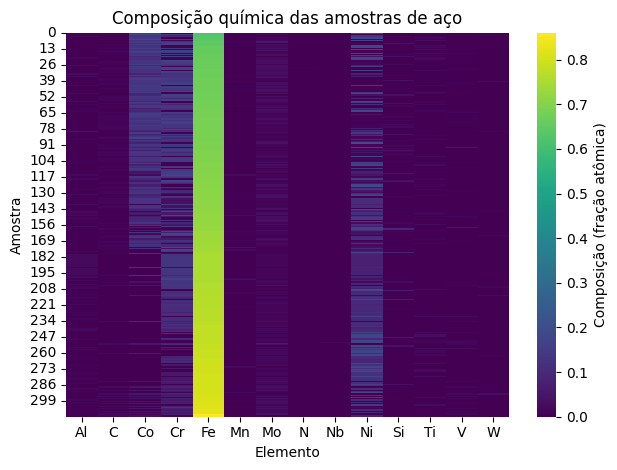

In [18]:
sns.heatmap(
    X,
    cmap="viridis",
    cbar_kws={"label": "Composição (fração atômica)"}
)

plt.xlabel("Elemento")
plt.ylabel("Amostra")
plt.title("Composição química das amostras de aço")

plt.tight_layout()
plt.show()

Temos um problema (mais um) de visualização: como Fe é muito mais abundante que os elementos de liga, ele domina visualmente o heatmap. Por isso, vamos fazer uma versão sem Fe para enxergar melhor as variações dos elementos de liga.

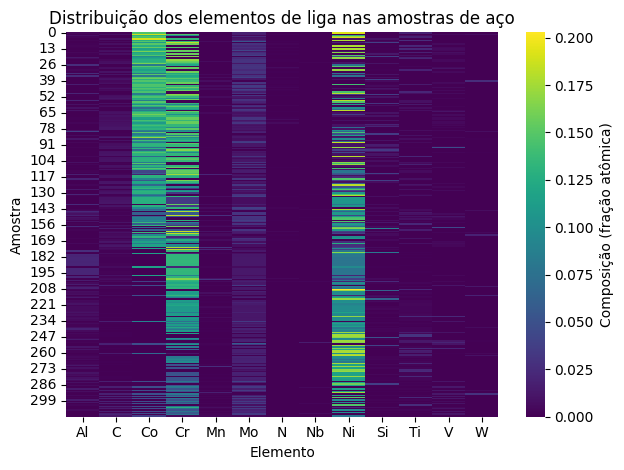

In [19]:
outros_elementos = [element for element in elements if element != "Fe"]
sns.heatmap(
    X[outros_elementos],
    cmap="viridis",
    cbar_kws={"label": "Composição (fração atômica)"}
)

plt.xlabel("Elemento")
plt.ylabel("Amostra")
plt.title("Distribuição dos elementos de liga nas amostras de aço")

plt.tight_layout()
plt.show()

Observando o gráfico, podemos ver a dominância de 3 elementos nas ligas: Cobalto, Cromo e Níquel. Essa diferença mostra que o dataframe contém famílias diferentes de ligas de aço. Isso é interessantíssimo para observarmos como as diferentes ligas mudam a tensão de escoamento do aço.

## Preparação dos dados

Iniciamos, nessa sessão, a preparação dos dados para a indução dos modelos. Podemos iniciar esse processo pelas features e target.

Como vimos anteriormente, o conjunto de features serão os elementos da composição química da amostra, dados em um dataframe separado e que é identificado pela variável X.

In [20]:
print(X)

           Al         C        Co        Cr        Fe        Mn        Mo  \
0    0.003180  0.000953  0.145992  0.000110  0.619964  0.000521  0.017599   
1    0.000845  0.008542  0.188034  0.147026  0.623112  0.000104  0.017903   
2    0.008123  0.000000  0.132042  0.093630  0.625199  0.000102  0.004802   
3    0.002772  0.000478  0.146091  0.000111  0.634395  0.000523  0.023715   
4    0.002740  0.000474  0.143997  0.000109  0.635985  0.000518  0.008600   
..        ...       ...       ...       ...       ...       ...       ...   
307  0.000620  0.017600  0.046300  0.077900  0.822998  0.001830  0.021900   
308  0.000629  0.000000  0.000096  0.056101  0.823012  0.000618  0.018900   
309  0.000628  0.017401  0.046804  0.056505  0.825070  0.001750  0.034403   
310  0.000623  0.019106  0.000190  0.075322  0.858251  0.001941  0.034110   
311  0.000619  0.012505  0.036914  0.004392  0.860334  0.002741  0.002841   

           N        Nb        Ni        Si        Ti         V         W  


O target é a tensão de escoamento, que tem também um dataframe identificado pela variável y.

In [21]:
print(y)

0      2411.5
1      1123.1
2      1736.3
3      2487.3
4      2249.6
        ...  
307    1722.5
308    1019.0
309    1860.3
310    1812.1
311    1139.7
Name: yield strength, Length: 312, dtype: float64


### Separação entre treinamento e teste

Como já vimos anteriormente, uma ótima estratégia é separar os dados entre dados de treino e de teste para a indução dos modelos. Essa estratégia é colocada em prática por meio da função train_test_split do módulo scikit-learn (já utilizamos essa função anteriormente nesse notebook).

Nesse caso, vamos seguir a recomendação da literatura: utilizaremos 85% dos dados para treino e 15% para teste. Ademais, também utilizaremos uma semente aleatória que já foi definida anteriormente nesse notebook para garantir a reprodutibilidade dos resultados.

In [22]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.15

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)

Com isso, teremos: 265 dados para treino e 47 dados para teste.

# Antes do XGBoost: estabelecendo referências

Já vimos a teoria da maioria desses modelos anteriormente nesse notebook. Agora vamos colocá-la em prática para esse problema com o intuito de comparar o desempenho de diferentes modelos para o mesmo problema.

## Modelo baseline

Este é o tipo de modelo que chamamos de *dummy*, *baseline*, linha de base ou modelo fictício. Trata-se de um modelo muito simples que podemos usar para comparar o desempenho de modelos mais complexos. Qualquer modelo com desempenho *pior* que um modelo baseline é um modelo considerado bastante ruim.

>Quanto podemos prever utilizando apenas uma estratégia 'boba'?

In [23]:
from sklearn.dummy import DummyRegressor

modelo_baseline = DummyRegressor()
modelo_baseline.fit(X_treino, y_treino)
y_previsto_baseline = modelo_baseline.predict(X_teste)

O modelo está treinado, mantenha a calma que vamos comparar todos de uma vez em uma sessão separada.

## Árvore de decisão

Para essa árvore de decisão, utilizaremos um valor de profundidade igual à quatro, pois é um valor razoável tendo em vista os testes que fizemos anteriormente.

In [24]:
from sklearn.tree import DecisionTreeRegressor

PROFUNDIDADE = 4

modelo_arvore = DecisionTreeRegressor(max_depth=PROFUNDIDADE, random_state=SEMENTE_ALEATORIA)

modelo_arvore.fit(X_treino, y_treino)

y_verdadeiro = y_teste
y_previsto_arvore = modelo_arvore.predict(X_teste)

O modelo está treinado, vamos treinar o próximo para que possamos compará-los ao final.

## Floresta aleatória 

Vamos utilizar os mesmos dados que carregamos acima. Primeiramente, vamos criar uma instância para o modelo:

In [25]:
from sklearn.ensemble import RandomForestRegressor


NUM_ÁRVORES = 300
NUM_FOLHAS = None
NUM_PROFUNDIDADE = None

modelo_floresta = RandomForestRegressor(
        n_estimators=NUM_ÁRVORES,
        max_leaf_nodes=NUM_FOLHAS,
        max_depth=NUM_PROFUNDIDADE,
        random_state=SEMENTE_ALEATORIA
        )

Agora vamos treinar o modelo. E utilizar os hiperparâmetros que tiveram melhor desempenho no modelo que foi apresentado na aula 4.0 de Árvores de decisão e floresta aleatória (do prof. Dr. Daniel Roberto Cassar).

In [26]:
modelo_floresta.fit(X_treino, y_treino)

y_verdadeiro = y_teste
y_previsto_floresta = modelo_floresta.predict(X_teste)

O penúltimo modelo foi treinado, vamos, agora, treinar o modelo de XGBoost e comparar o seu desempenho com o desempenho dos demais modelos.

# XGBoost aplicado aos aços

Nessa sessão, vamos treinar o modelo de XGBoost utilizando o módulo scikit-learn.

Primordialmente, precisamos ter a biblioteca do XGBoost baixada. Para isso, vamos executar o seguinte código em uma célula abaixo:
>pip install xgboost

In [27]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


Nesse modelo, utilizaremos valores de hiperparâmetros arbitrários (sempre utilizando o bom senso). E, após compararmos os desempenhos dos modelos, vamos fazer a variação dos valores dos hiperparâmetros para encontrar possíveis valores 'ótimos' para o nosso modelo. 

Utilizaremos o XGBRegressor, visto que temos um problema de regressão nesse notebook.

In [28]:
from xgboost import XGBRegressor

TAXA_APRENDIZADO = 0.05
PROFUNDIDADE_MAXIMA = 7

modelo_xgb = XGBRegressor(
    n_estimators=NUM_ÁRVORES,
    learning_rate=TAXA_APRENDIZADO,
    max_depth=PROFUNDIDADE_MAXIMA,
    random_state=SEMENTE_ALEATORIA
)

modelo_xgb.fit(X_treino, y_treino)

y_previsto_xgb = modelo_xgb.predict(X_teste)

# Avaliação e comparação dos modelos

## Métricas

Avaliaremos o desempenho dos modelos utilizando as três métricas apresentadas anteriormente: RMSE, MAE e $R^2$. Vamos, a princípio observar os desempenho dos modelos tendo em vista que não foi feito nenhum ajuste ótimo nos parâmetros.

Vamos iniciar importando as métricas.

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

resultados = pd.DataFrame({
    'Modelo': ['Baseline', 'Árvore de Decisão', 'Floresta Aleatória', 'XGBoost'],
    'MAE': [
        mean_absolute_error(y_teste, y_previsto_baseline),
        mean_absolute_error(y_teste, y_previsto_arvore),
        mean_absolute_error(y_teste, y_previsto_floresta),
        mean_absolute_error(y_teste, y_previsto_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_teste, y_previsto_baseline)),
        np.sqrt(mean_squared_error(y_teste, y_previsto_arvore)),
        np.sqrt(mean_squared_error(y_teste, y_previsto_floresta)),
        np.sqrt(mean_squared_error(y_teste, y_previsto_xgb))
    ],
    'R²': [
        r2_score(y_teste, y_previsto_baseline),
        r2_score(y_teste, y_previsto_arvore),
        r2_score(y_teste, y_previsto_floresta),
        r2_score(y_teste, y_previsto_xgb)
    ]
})

resultados = resultados.round(4)

display(resultados)


,Modelo,MAE,RMSE,R²
0,Baseline,216.6638,273.4128,-0.0009
1,Árvore de Decisão,140.3446,165.7516,0.6322
2,Floresta Aleatória,100.2878,129.5421,0.7753
3,XGBoost,104.2592,137.7555,0.7459


Com os resultados em vista, podemos interpretar coisas muito interessantes.

Primeiramente, o modelo com um desempenho geral melhor foi o modelo de floresta aleatória. Isso pode ser explicado por vários motivos: além de não ter feito um ajuste de hiperparâmetros, o conjunto de dados possui uma quantidade limitada de amostras, dessa forma, os benefícios adicionais do mecanismo de boosting podem não ter sido plenamente explorados. Entretanto, a diferença observada entre os modelos foi pequena, sugerindo que ambos apresentaram capacidade preditiva semelhante para o conjunto de dados estudado.

O modelo baseline, por si só, apresenta um desempenho esperado, visto que ele foi utilizado como referência inicial, realizando previsões sem explorar as relações entre a composição química das ligas e a resistência mecânica. Seu desempenho inferior aos demais modelos era esperado, uma vez que o método não utiliza informações dos atributos para construir previsões. Ainda assim, ele fornece um ponto de comparação importante para avaliar o ganho obtido pelos algoritmos de aprendizado de máquina. O coeficiente de determinação (R²) do modelo Baseline foi próximo de zero, evidenciando que ele explica uma parcela desprezível da variabilidade observada nos dados. Em contraste, os modelos baseados em árvores apresentaram valores substancialmente maiores, demonstrando capacidade efetiva de capturar as relações entre os elementos químicos e a resistência ao escoamento.

A Árvore de Decisão apresentou desempenho intermediário, superando o modelo Baseline, mas ficando abaixo dos métodos de ensemble (Floresta Aleatória e XGBoost). Esse resultado indica que a árvore foi capaz de identificar relações entre a composição química das ligas e a resistência ao escoamento, porém sua estrutura baseada em uma única árvore limita a capacidade de generalização e a robustez do modelo.


É interessante refrescar a memória e lembrar as diferenças entre os dois modelos: a Floresta Aleatória constrói várias árvores independentemente. O XGBoost constrói as árvores sequencialmente e cada nova árvore tenta corrigir os erros das árvores anteriores. A previsão final é uma combinação ponderada de todas as árvores, por isso ele costuma conseguir modelar relações mais complexas.

A partir disso, podemos interpretar que um melhor desempenho do XGBoost não é necessariamente garantido. 



## Gráficos de desempenho

A partir das métricas, podemos plotar um gráfico de desempenho para observar visualmente a correspondência entre os valores previstos pelo modelo e os valores reais. Nesse sentido, plotaremos o gráfico de desempenho — gráfico que relaciona y_previsto com y_real e checa o seu desempenho na predição dos dados.

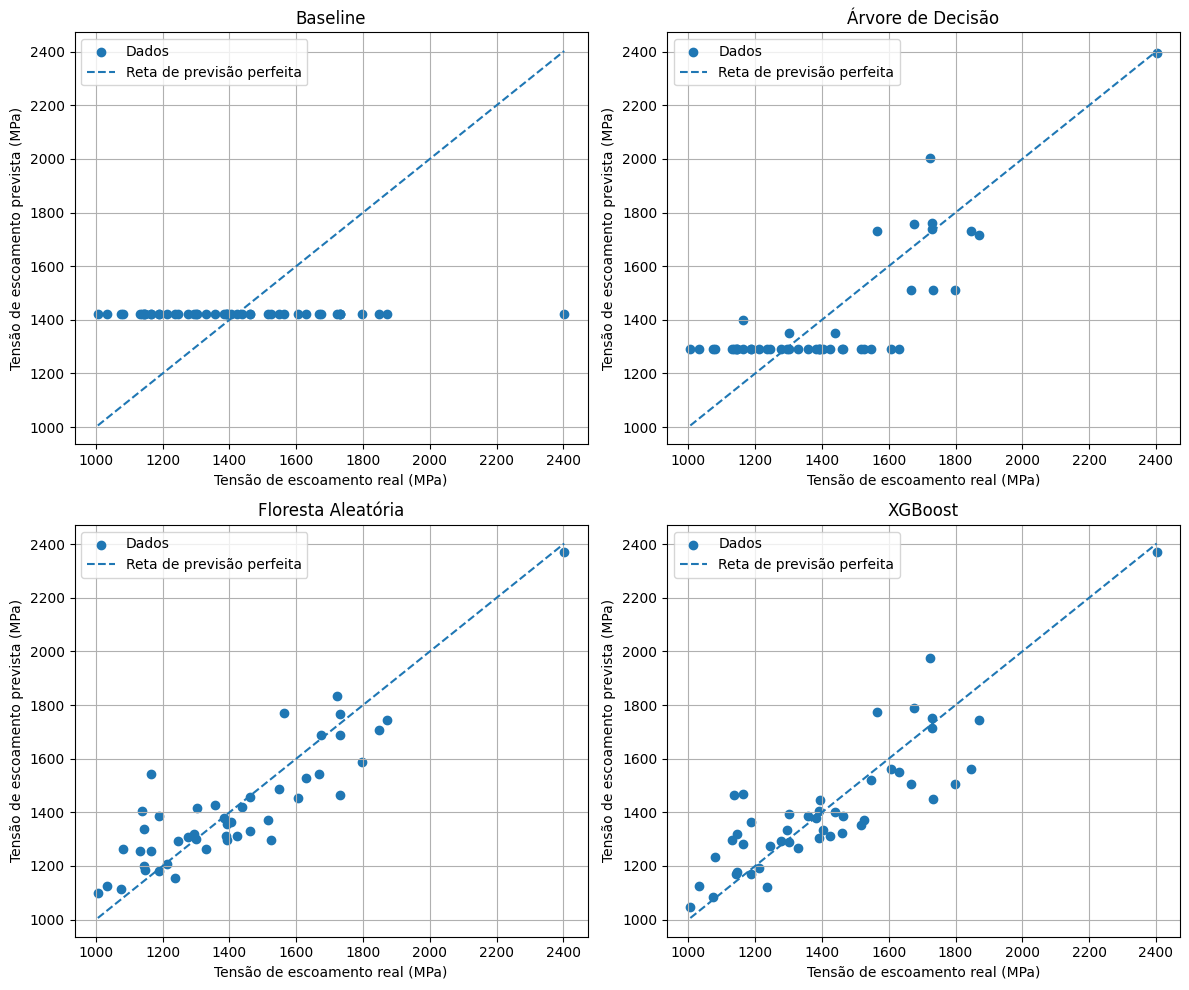

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

modelos = {
    "Baseline": y_previsto_baseline,
    "Árvore de Decisão": y_previsto_arvore,
    "Floresta Aleatória": y_previsto_floresta,
    "XGBoost": y_previsto_xgb
}

for ax, (nome, y_previsto) in zip(axes, modelos.items()):
    
    ax.scatter(y_teste, y_previsto, label="Dados")
    
    limite_min = min(y_teste.min(), y_previsto.min())
    limite_max = max(y_teste.max(), y_previsto.max())
    
    ax.plot(
        [limite_min, limite_max],
        [limite_min, limite_max],
        linestyle="--",
        label="Reta de previsão perfeita"
    )
    
    
    ax.set_title(nome)
    ax.set_xlabel("Tensão de escoamento real (MPa)")
    ax.set_ylabel("Tensão de escoamento prevista (MPa)")
    ax.legend()
    ax.grid()
    

plt.tight_layout()
plt.show()

Para intepretamos um gráfico de desempenho, temos que ter em vista que o eixo X é a tensão de escoamento real e o eixo Y é a tensão de escoamento que o modelo prevê. A reta pontilhada é a reta de previsão perfeita, idealmente, em uma previsão perfeita, todos os pontos estariam sobre ela se o modelo previsse perfeitamente os dados. Nesse contexto, o afastamento dos pontos(dados) em relação à reta pontilhada representa o quanto o modelo errou nas suas predições.

Podemos observar visualmente o que o resultado das métricas nos disse anteriormente: a floresta aleatória e o XGBoost tiveram os melhores desempenhos e conseguiram prever de maneira satisfatória a maioria dos valores. Isso porque, os pontos não se afastaram tanto da reta de previsão perfeita. Todavia, o seu desempenho não foi excelente, pois muitos pontos se afastam da previsão perfeita, mostrando as limitações de predição de ambos modelos.

# Experimento adicional: otimização dos hiperparâmetros

Anteriormente foi frisado que o modelo XGBoost foi induzido com hiperparâmetros arbitrários. Nessa sessão, vamos otimizar os hiperparâmetros e induzir um novo modelo, observando uma possível melhora no seu desempenho. Para isso, utilizaremos um método automático de otimização de hiperparâmetros usando validação cruzada, podendo, assim, comparar o desempenho dos modelos com base no conjunto de teste.

Utilizaremos o RandomizedSearchCV, uma classe da biblioteca Scikit-Learn em Python usada para otimizar hiperparâmetros de modelos de aprendizado de máquina por meio de uma busca aleatória. Ele, em vez de testar todas as combinações possíveis de parâmetros, seleciona uma quantidade fixa de combinações de forma randômica para avaliar o desempenho do modelo.

Seu funcionamento segue quatro passos:

- Amostragem Aleatória: O algoritmo escolhe aleatoriamente valores dentro de intervalos ou distribuições de probabilidade que você define para cada hiperparâmetro; 

- Número de Iterações: O argumento n_iter define quantas combinações diferentes o programa vai testar;

- Validação Cruzada: Cada combinação escolhida é avaliada usando validação cruzada (k-fold cross-validation) para garantir que a nota do modelo seja confiável; 

- Melhor Resultado: Ao final das rodadas, a ferramenta guarda e retorna o conjunto de parâmetros que obteve a melhor métrica de desempenho.

OBS.: como temos um conjunto menor de dados, não é necessário fazer uma busca grande para encontrar bons hiperparâmetros. Com isso, os valores no espaço de busca serão razoáveis, mas não muito altos, já que não é necessário.

Podemos iniciar esse processo importando a biblioteca e determinando o espaço de busca para cada um dos hiperparâmetros:

A tabela a seguir mostra os valores utilizados para o espaço de busca:

| Hiperparâmetro     | Valores    | Justificativa                                                                                         |
| ------------------ | ---------  | ----------------------------------------------------------------------------------------------------- |
| `n_estimators`     | 100–600    | Testa desde modelos relativamente simples até modelos com mais árvores                                |
| `learning_rate`    | 0.005–0.20 | Explora taxas de aprendizado pequenas a moderadas                                                     |
| `max_depth`        | 2–10       | Permite árvores rasas, intermediárias e mais complexas sem favorecer árvores excessivamente profundas |
| `subsample`        | 0.1–1.0    | Testa o efeito de usar uma fração das amostras em cada etapa                                          |

Além disso, temos também os parâmetros do otimizador:

- __n_iter=1500__ : Temos 11088 configurações possíveis e testaremos 1500 dessas possibilidades (selecionadas aleatoriamente); 

- __cv=5__ : o conjunto de treinamento é dividido em cinco partes. Para cada configuração: treina em 4 partes, valida na parte restante, repete isso cinco vezes e calcula o desempenho médio;

- __scoring="neg_root_mean_squared_error"__ : estamos buscando medir o RMSE, pois ele é a métrica mais intuitiva de desempenho para o nosso caso (MPa).

- __n_jobs__ : definido como -1 para permitir a execução paralela das diferentes combinações de hiperparâmetros e folds da validação cruzada, utilizando os núcleos disponíveis do processador e reduzindo o tempo computacional da busca.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

parametros = {
    "n_estimators": [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600],
    "learning_rate": [0.005, 0.01, 0.03, 0.04, 0.05, 0.07, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "subsample": [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0],
}

modelo_xgb_otimizado = XGBRegressor(
    random_state=SEMENTE_ALEATORIA
)

busca = RandomizedSearchCV(
    modelo_xgb_otimizado,
    parametros,
    n_iter=1500,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=SEMENTE_ALEATORIA,
    n_jobs=-1
)

busca.fit(X_treino, y_treino)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.005, 0.01, ...], 'max_depth': [2, 3, ...], 'n_estimators': [100, 150, ...], 'subsample': [0.3, 0.35, ...]}"
,n_iter,1500
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,210906
,error_score,nan


Com a busca finalizada, vamos ver quais são os melhores valores de hiperparâmetros encontrados:

In [ ]:
print("Melhores parâmetros:")
print(busca.best_params_)


Melhores parâmetros:
{'subsample': 0.45, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.07}


## Indução do modelo otimizado

Agora vamos refazer a simulação do modelo com os hiperparâmetros encontrados anteriormente e checar a sua possível melhora.

In [ ]:
modelo_xgb_otimizado = busca.best_estimator_

y_previsto_xgb_otimizado = modelo_xgb_otimizado.predict(X_teste)

rmse_original = np.sqrt(
    mean_squared_error(y_teste, y_previsto_xgb)
)

rmse_otimizado = np.sqrt(
    mean_squared_error(y_teste, y_previsto_xgb_otimizado)
)


melhora_rmse = (rmse_original-rmse_otimizado)/ rmse_original 

print(f'A melhora encontrada na métrica RMSE foi de {melhora_rmse*100} %')

r2_original = r2_score(y_teste, y_previsto_xgb)
r2_otimizado = r2_score(y_teste, y_previsto_xgb_otimizado)
print('--------------------------------')
melhora_r2 = (r2_otimizado-r2_original) / r2_original
print(f'A melhora encontrada na métrica R2 foi de {melhora_r2*100} %')

print('-----------------------')

mae_original = mean_absolute_error(y_teste, y_previsto_xgb)
mae_otimizado = mean_absolute_error(y_teste, y_previsto_xgb_otimizado)

melhora_mae = (mae_original - mae_otimizado) / mae_original
print(f'A melhora encontrada na métrica MAE foi de {melhora_mae*100} %')

A melhora encontrada na métrica RMSE foi de 4.306388519431383 %
--------------------------------
A melhora encontrada na métrica R2 foi de 2.870385015431757 %
-----------------------
A melhora encontrada na métrica MAE foi de -1.2683206385896608 %


Os resultados indicam que o ajuste dos hiperparâmetros pode melhorar o desempenho do modelo para esse conjunto de dados, embora a melhoria observada tenha sido relativamente pequena.

Nas alterações feitas pelo ajuste dos hiperparâmetros, o otimizador manteve n_estimators e max_depth e alterou principalmente learning_rate e subsample. O modelo otimizado usa apenas 45% das amostras em cada etapa, contra 100% no modelo original (visto que utilizamos o valor padrão). Entende-se que, para esse conjunto de dados, introduzir mais aleatoriedade no treinamento pode ter ajudado o XGBoost a reduzir a dependência das árvores em relação às mesmas amostras, diminuindo o risco de overfitting.

O learning_rate passou de 0,05 para 0,07, explicitando que o modelo otimizado dá, portanto, um pouco mais de peso para cada nova árvore.

## Gráfico de desempenho

Podemos plotar dois gráficos de desempenho para comparar a melhora do primeiro modelo para o segundo.

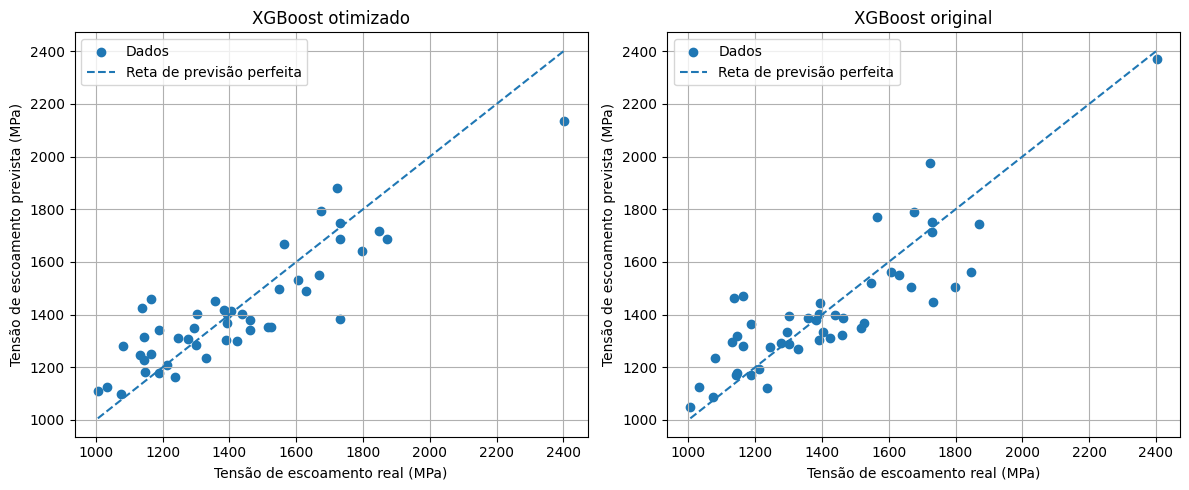

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

modelos = {
    "XGBoost otimizado": y_previsto_xgb_otimizado,
    "XGBoost original": y_previsto_xgb
}

for ax, (nome, y_previsto) in zip(axes, modelos.items()):
    
    ax.scatter(y_teste, y_previsto, label="Dados")
    
    limite_min = min(y_test.min(), y_pred.min())
    limite_max = max(y_test.max(), y_pred.max())
    
    ax.plot(
        [limite_min, limite_max],
        [limite_min, limite_max],
        linestyle="--",
        label="Reta de previsão perfeita"
    )
    
    
    ax.set_title(nome)
    ax.set_xlabel("Tensão de escoamento real (MPa)")
    ax.set_ylabel("Tensão de escoamento prevista (MPa)")
    ax.legend()
    ax.grid()
    

plt.tight_layout()
plt.show()

Visualizando os gráficos, podemos perceber que realmente há uma mudança sutil nas duas previsões. Entretanto, não é possível afirmar que houve uma mudança revolucionária, houve apenas uma melhora sutil (e quase desprezível) nas previsões.

# Discussão e aprendizados

Voltando para a problemática criada no início desse notebook:

>Portanto, nesse notebook, vamos investigar até que ponto um modelo de aprendizado de máquina pode aprender padrões presentes nos dados que permitam estimar a tensão de escoamento a partir da composição química.

A partir dos resultados, podemos dizer que é possível sim estimar a tensão de escoamento de aços a partir da sua composição química, porém com certas ressalvas. A priori, é possível criticar as features utilizadas para a predição, pois, em um aço real, além da composição química, também existem variáveis importantes como: tamanho do grão, fases presentes, impurezas e processamento térmico (referência [20]). Com isso, apesar do modelo apresentar desempenho satisfatório para a previsão da tensão de escoamento, apresentando R² = 0,77 e RMSE = 131 MPa no conjunto de teste, ele ainda sim é limitado, já que não é possível prever uma propriedade mecânica complexa utilizando apenas a composição química. 

Ademais, a sua utilização também é um tema de possível discussão. Por se tratar de um dataset pequeno (apenas 312 amostras) em que a predição é feita desconsiderado fatores importantes, não é possível dizer que esse é um ótimo modelo para predição em situações reais. Isso porque, apesar de ele possuir uma predição satisfatória da tensão de escoamento, existe uma parcela significativa da variabilidade que a composição isoladamente não captura. 

Portanto, o modelo pode ser utilizado para estimar aproximadamente a tensão de escoamento, mas com cautela, tendo em vista que é apenas uma estimativa e não substitui medições experimentais. 

É possível destacar que, na produção desse notebook, foi possível compreender melhor como o aprendizado de máquina pode ser utilizado em situações reais, especificamente para a área de ciência dos materiais. A produção de um material didático foi, na minha visão, a melhor forma para aprender e organizar o conhecimento de forma sólida e independente. Ao utilizar as bibliotecas desse notebook, pude compreendê-las de forma mais aprofundada, de forma que os saberes adquiridos durante a produção desse material serão fundamentais para o meu futuro profissional.

Além disso, pude entender melhor como guiar o leitor em um notebook didático. O refinamento na escrita e escolha dos termos mais corretos academicamente são habilidades que foram trabalhadas durante a produção deste material didático.

# Limitações

Essa breve sessão tem o intuito de pontuar uma ideia central para o leitor:

>Predição ≠ Causalidade

Neste notebook, trabalhamos a utilização do machine learning aplicado à ciência e buscamos estimar o futuro ou o valor desconhecido (y) com base em features (X) por meio da predição de valores. 

O modelo opera identificando padrões e correlações multidimensionais nos dados de entrada. Se o algoritmo associa o aumento de um elemento \(X\) à elevação da tensão de escoamento, isso constitui uma predição válida, mas não uma explicação física.

Portanto, esse modelo falha em responder à pergunta: "Por que essa composição altera a resistência?". Na ciência dos materiais, a causa direta do aumento da tensão de escoamento reside em fenômenos físicos reais — como o ancoramento de discordâncias, o refino de grão ou a precipitação de fases. O algoritmo não possui nenhuma representação dessas leis da física ou da termodinâmica; ele opera apenas com a covariância dos dados estruturados.

# Conclusão

Neste notebook, pudemos percorrer os modelos preditivos que são a base para o entendimento. Partindo de árvores de decisão, introduzimos ensembles, diferenciamos Random Forest e Boosting, chegamos ao Gradient Boosting e apresentamos o XGBoost. Neste caminho, compreendemos conceitos básicos do Machine Learning que possibilitaram a posterior compreensão de modelos preditivos complexos, seguindo um caminho progressivo e bem definido.

Também foi possível realizar aplicação do XGBoost a um problema de ciência dos materiais. Na qual realizou-se uma análise exploratória e preditiva de um conjunto de dados contendo composições químicas de ligas de aço e seus respectivos valores de resistência ao escoamento (yield strength). Em seguida, foram treinados e avaliados diferentes modelos de regressão: Baseline, Árvore de Decisão, Floresta Aleatória e XGBoost. As métricas de avaliação utilizadas foram o erro absoluto médio (MAE), a raiz do erro quadrático médio (RMSE) e o coeficiente de determinação (R²).

Os resultados mostraram que o modelo Baseline apresentou o menor desempenho, servindo apenas como referência para comparação. A Árvore de Decisão foi capaz de capturar parte dos padrões presentes nos dados, obtendo desempenho intermediário. Os modelos de ensemble, Floresta Aleatória e XGBoost, apresentaram desempenho superior ao da Árvore de Decisão e do modelo baseline, com a Floresta Aleatória apresentando o melhor desempenho entre os modelos avaliados inicialmente.

A otimização dos hiperparâmetros do XGBoost foi realizada e um novo modelo otimizado foi induzido. O modelo otimizado teve um desempenho ligeiramente superior ao modelo não-otimizado, apresentando uma leve melhora na capacidade de predição.

Além disso, pontuamos também a diferença de predição e explicação, mostrando que um não implica no outro e que o algoritmo não se baseia em leis físicas, mas sim nos padrões que podem ser captados do dataset.


Dessa forma, conclui-se que técnicas de aprendizado de máquina baseadas em árvores constituem ferramentas eficazes para a previsão da resistência ao escoamento de ligas metálicas a partir de sua composição química.

# Descrição do uso de IA neste trabalho

Na produção deste notebook didático, utilizei a IA generativa Chat GPT em sua versão GPT-5.6 Luna para me auxiliar na construção do material. Primeiramente, utilizei a IA para discutir sobre qual dos temas apresentados seria o melhor, tendo em vista os meus objetivos acadêmicos. Com o tema em vista, enviei o enunciado e pedi para que a IA produzisse um 'plano de texto' contendo tudo o que eu deveria estudar e escrever com base no que era esperado desse notebook segundo o professor. 

Ademais, ela me ajudou a encontrar um dataset da área de ciência dos materiais para ser utilizado no notebook, assim, fui encaminhado ao site do matminer e pude escolher o dataset que eu mais achasse razoável para a utilização em um notebook introdutório. A IA também me auxiliou na classificação dos materiais de aprendizado que eu utilizei para estudo, visto que eu não tinha tempo para me aprofundar de forma desnecessária para não perder tempo.

No tocante à compreensão dos modelos, também utilizei a inteligência artificial para esclarecer certos conceitos que eu não possuía uma compreensão clara, de forma que, ao fornecer uma explicação, ela me corrigia e mostrava quais partes do meu raciocínio estavam incorretas. Assim como ela também me ajudou a compreender como certos códigos funcionavam, ajudando-me na depuração e revisão de certos códigos que eu tentei produzir, ou de códigos que vi em sites e não estava compreendendo.

Pedi também sugestões de visualizações interessantes para o notebook, reforçando o interesse de torná-lo o mais didático e visualmente interessante para o leitor. Assim, fui auxiliado na plotagem de certos gráficos que eu nunca tinha utilizado em outros notebooks (heatmaps, principalmente).

Por fim, a IA me auxiliou na revisão ortográfica e conceitual do notebook e na estruturação da escrita do README para posterior envio no Github.

A partir disso, é importante deixar explícitos que os códigos foram executados pelo autor. Os resultados obtidos foram verificados e as decisões metodológicas foram analisadas criticamente para a produção desse notebook.

# Referências

## Aprendizado de máquina e imagens

[1] ÁRVORES de decisão: modelos de classificação e regressão. Alura, 22 out. 2024. Disponível em: <https://www.alura.com.br/artigos/arvores-de-decisao>. Acesso em: 31 ago. 2026.

[2] SONI, Brijesh. Boost your machine learning models with bagging: a powerful ensemble learning technique. Medium, 25 abr. 2023. Disponível em: <https://medium.com/@brijesh_soni/boost-your-machine-learning-models-with-bagging-a-powerful-ensemble-learning-technique-692bfc4d1a51>. Acesso em: 2 set. 2026

[3] RAY, Debisree. A comprehensive guide to random forests. Data Science Collective, Medium, 11 set. 2025. Disponível em: <https://medium.com/data-science-collective/a-comprehensive-guide-to-random-forests-8d840c902dd5>. Acesso em: 2 set. 2026.

[4] RAY, Debisree. Bagging vs boosting: a deep dive into ensemble learning for tree-based models. Data Science Collective, Medium, 2 nov. 2025. Disponível em: <https://medium.com/data-science-collective/bagging-vs-boosting-a-deep-dive-into-ensemble-learning-for-tree-based-models-b3a061da3e62>. Acesso em: 8 set. 2026.

[5] ALENCAR, Valquíria. Técnica de boosting para aprimorar modelos de regressão. Alura, 10 jul. 2024. Disponível em: <https://www.alura.com.br/artigos/metodo-boosting>. Acesso em: 8 set. 2026


[6] CASSAR, Daniel Roberto. ATP-203 2.1 - Aprendizado de máquina, k-NN e métricas. Material didático. Ilum Escola de Ciência, Centro Nacional de Pesquisa em Energia e Materiais (CNPEM), 2026.

[7] CASSAR, Daniel Roberto. ATP-203 2.2 - Divisão de dados em treino e teste. Material didático. Ilum Escola de Ciência, Centro Nacional de Pesquisa em Energia e Materiais (CNPEM), 2026.

[8] CASSAR, Daniel Roberto. ATP-203 3.0 - Modelo linear e baseline. Material didático. Ilum Escola de Ciência, Centro Nacional de Pesquisa em Energia e Materiais (CNPEM), 2026.

[9] CASSAR, Daniel Roberto. ATP-203 4.0 - Árvore de decisão e floresta aleatória. Material didático. Ilum Escola de Ciência, Centro Nacional de Pesquisa em Energia e Materiais (CNPEM), 2026.

[10] DUBIELLA, Larissa. Métricas de avaliação para modelos de regressão. Alura, 3 nov. 2024. Disponível em: <https://www.alura.com.br/artigos/metricas-de-regressao>. Acesso em: 9 set. 2026.

[11] SCIKIT-LEARN DEVELOPERS. DecisionTreeRegressor. Scikit-learn Documentation. Disponível em: <https://scikit-learn.org/stable/modules/generatedsklearn.tree.DecisionTreeRegressor.html>. Acesso em: 31 ago. 2026.

[12] HYPERPARAMETER tuning. GeeksforGeeks, 26 jun. 2026. Disponível em: <https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning/>. Acesso em: 9 set. 2026.

[13] INRIA. Machine learning in Python with scikit-learn. Scikit-learn MOOC. Disponível em: <https://inria.github.io/scikit-learn-mooc/>. Acesso em: 9 set. 2026

[14] FACELI, Katti; LORENA, Ana Carolina; GAMA, João et al. Inteligência artificial: uma abordagem de aprendizado de máquina. 2. ed. Rio de Janeiro: LTC, 2021.

[15] DIDÁTICA TECH. Como funciona o algoritmo de Bagging? (Machine Learning). Disponível em: <https://didatica.tech/como-funciona-o-algoritmo-de-bagging/>. Acesso em: 12 set. 2026.

## XGBoost

[16] XGBOOST DEVELOPERS. XGBoost documentation. Disponível em: <https://xgboost.readthedocs.io/en/stable/>. Acesso em: 12 set. 2026.

[17] Tianqi Chen and Carlos Guestrin. 2016. XGBoost: A Scalable Tree Boosting System. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '16). Association for Computing Machinery, New York, NY, USA, 785–794. https://doi.org/10.1145/2939672.2939785

## IA

[18] OPENAI. Esfinge. ChatGPT, 2026. Disponível em: <https://chatgpt.com/share/6aa571be-6ed8-83e9-86b3-eeadf020b87d>. Acesso em: 4 set. 2026.

## Ciência dos Materiais e Dataset

[19] Ward, L., Dunn, A., Faghaninia, A., Zimmermann, N. E. R., Bajaj, S., Wang, Q., Montoya, J. H., Chen, J., Bystrom, K., Dylla, M., Chard, K., Asta, M., Persson, K., Snyder, G. J., Foster, I., Jain, A., Matminer: An open source toolkit for materials data mining. Comput. Mater. Sci. 152, 60-69 (2018).

[20] MAGENFER FERRO E AÇO. O que é: escoamento de aço. 19 set. 2024. Disponível em: <https://magenfer.com.br/glossario/o-que-e-escoamento-de-aco/>. Acesso em: 7 set. 2026

[21] CITRINATION. Mechanical properties of some steels. Dataset ID 153092, versão 3. Contribuição de Gareth Conduit (University of Cambridge) e Intellegens. 2017. Disponível em: <https://citrination.com/datasets/153092/show_files/>. Acesso em: 12 set. 2026.